In [14]:
import sys
sys.path.append('../src')

In [15]:
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import numpy as np

In [16]:
from context import TriangleIntegrandContext
from integrand_builder import IntegrandBuilder

from context import TriangleIntegrandEvaluator
from wrapped_eval import WrappedEvaluator

ctx = TriangleIntegrandContext()

ib_centered = IntegrandBuilder()
ib_centered.smooth_mask = False
ib_centered.check_singularities_per_sample = False # not necessary for this example, improves performance
ib_centered.center_counterterm_region_at_origin = True
ib_uncentered = IntegrandBuilder()
ib_uncentered.smooth_mask = False
ib_uncentered.check_singularities_per_sample = False # not necessary for this example, improves performance
ib_uncentered.center_counterterm_region_at_origin = False
ib_variable = IntegrandBuilder()
ib_variable.center_counterterm_region_at_origin = False
ib_variable.center_counterterm_region_at_origin = False
ib_variable.use_complex_dist = True

centered = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib_centered.combined_result(), ib_centered.get_args(), "centered_theta"), ctx
)
uncentered = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib_uncentered.combined_result(), ib_uncentered.get_args(), "uncentered_theta"), ctx
)
variable = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib_variable.combined_result(), ib_variable.get_args(), "variable_theta"), ctx
)

Compiling evaluator: "centered_theta"
Done!
Compiling evaluator: "uncentered_theta"
Done!
Compiling evaluator: "variable_theta"
Done!


# plot the integrand and threshold subtraction

<Figure size 2000x1000 with 0 Axes>

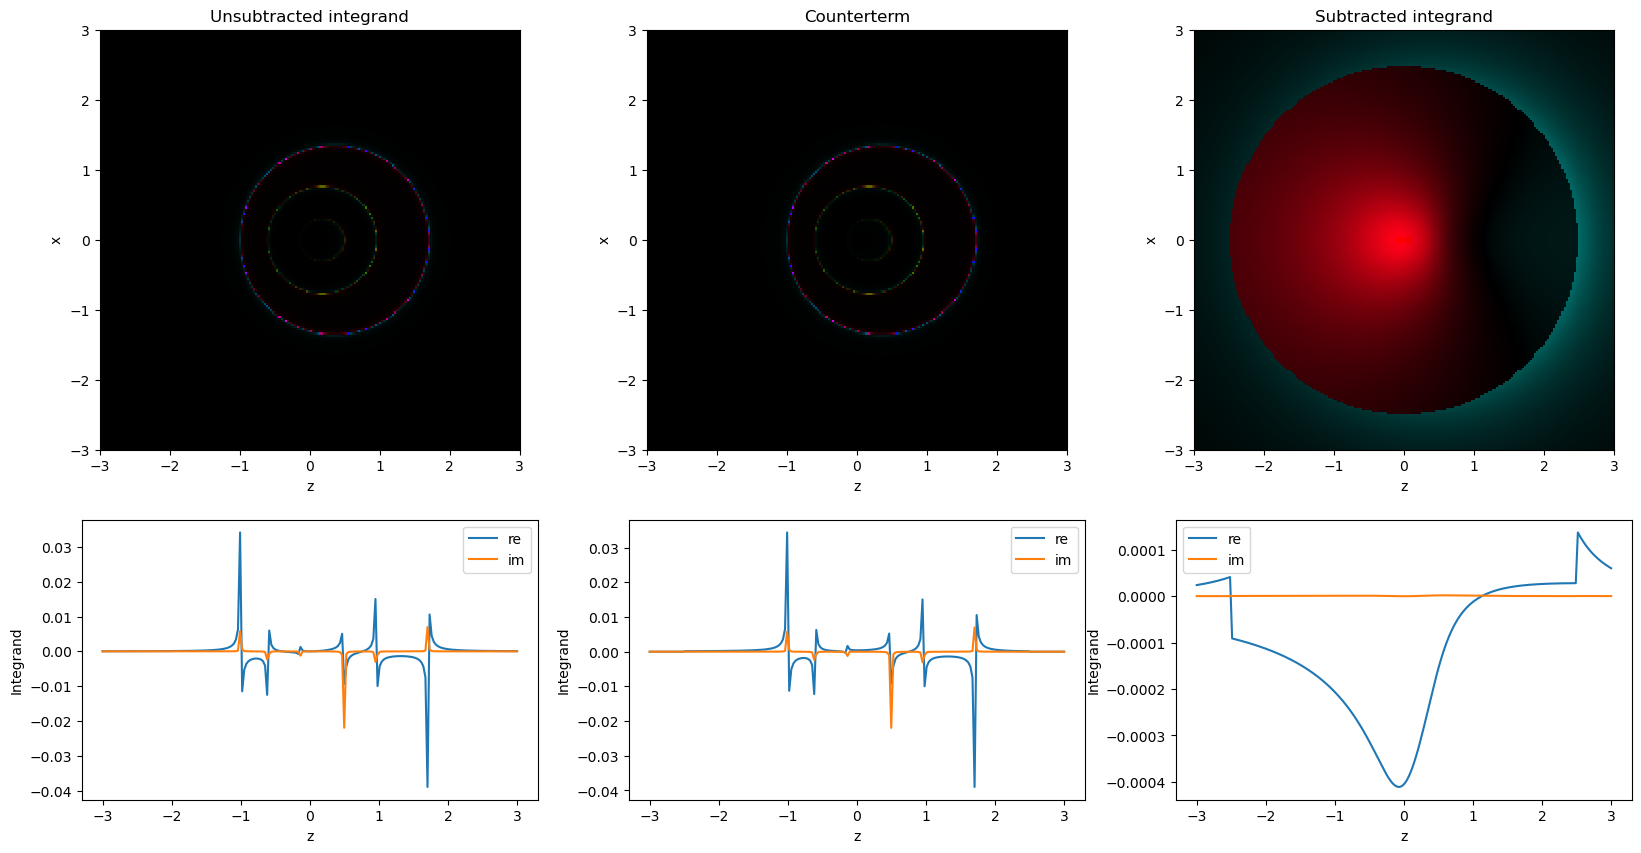

<Figure size 2000x1000 with 0 Axes>

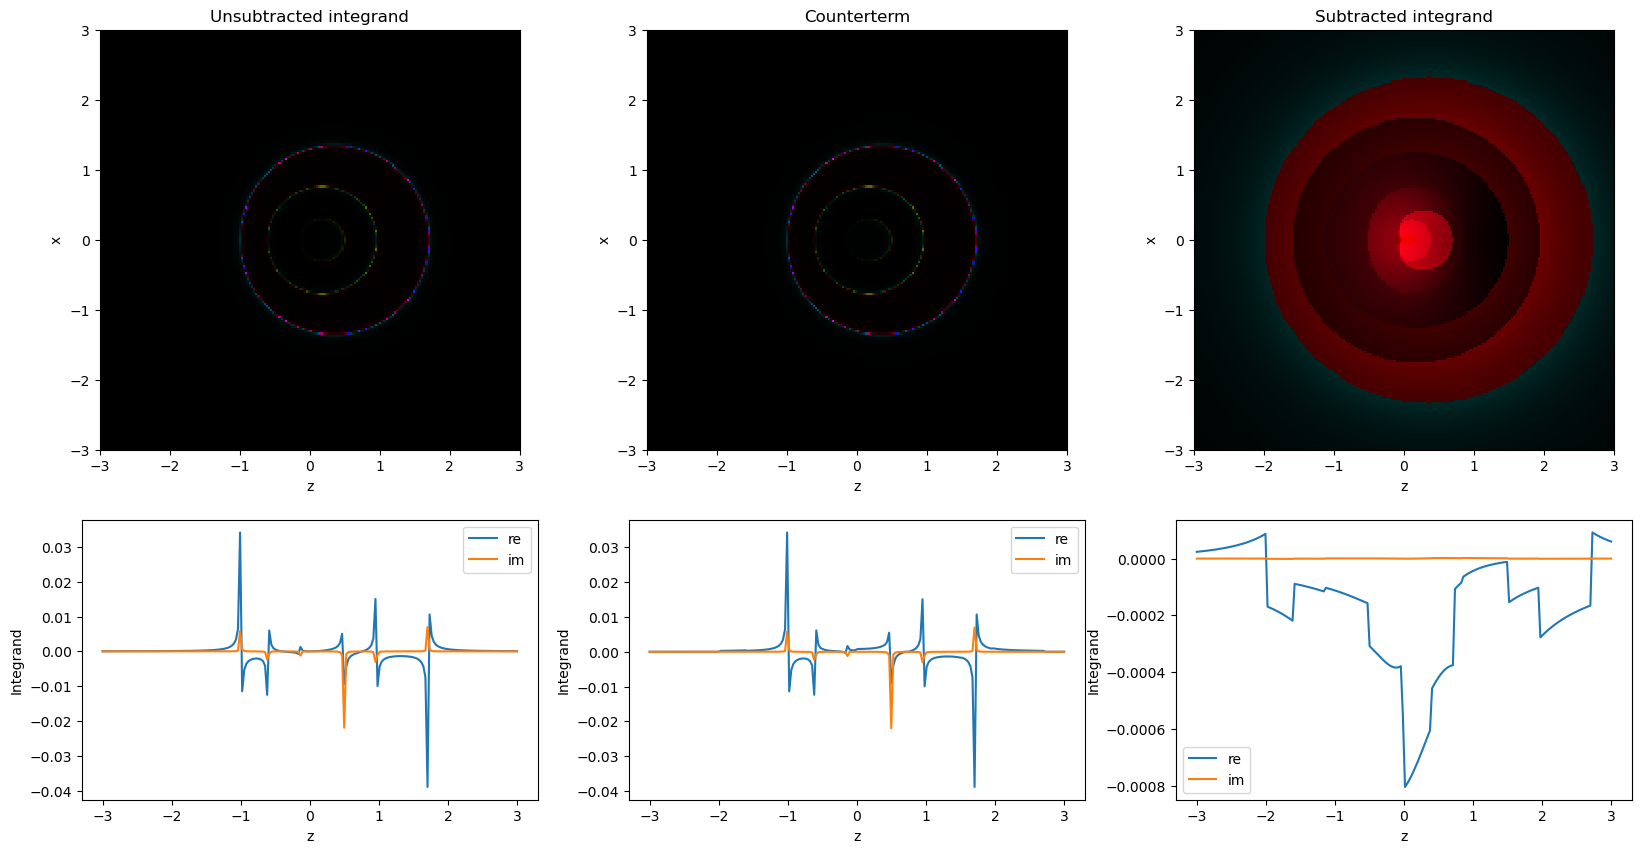

<Figure size 2000x1000 with 0 Axes>

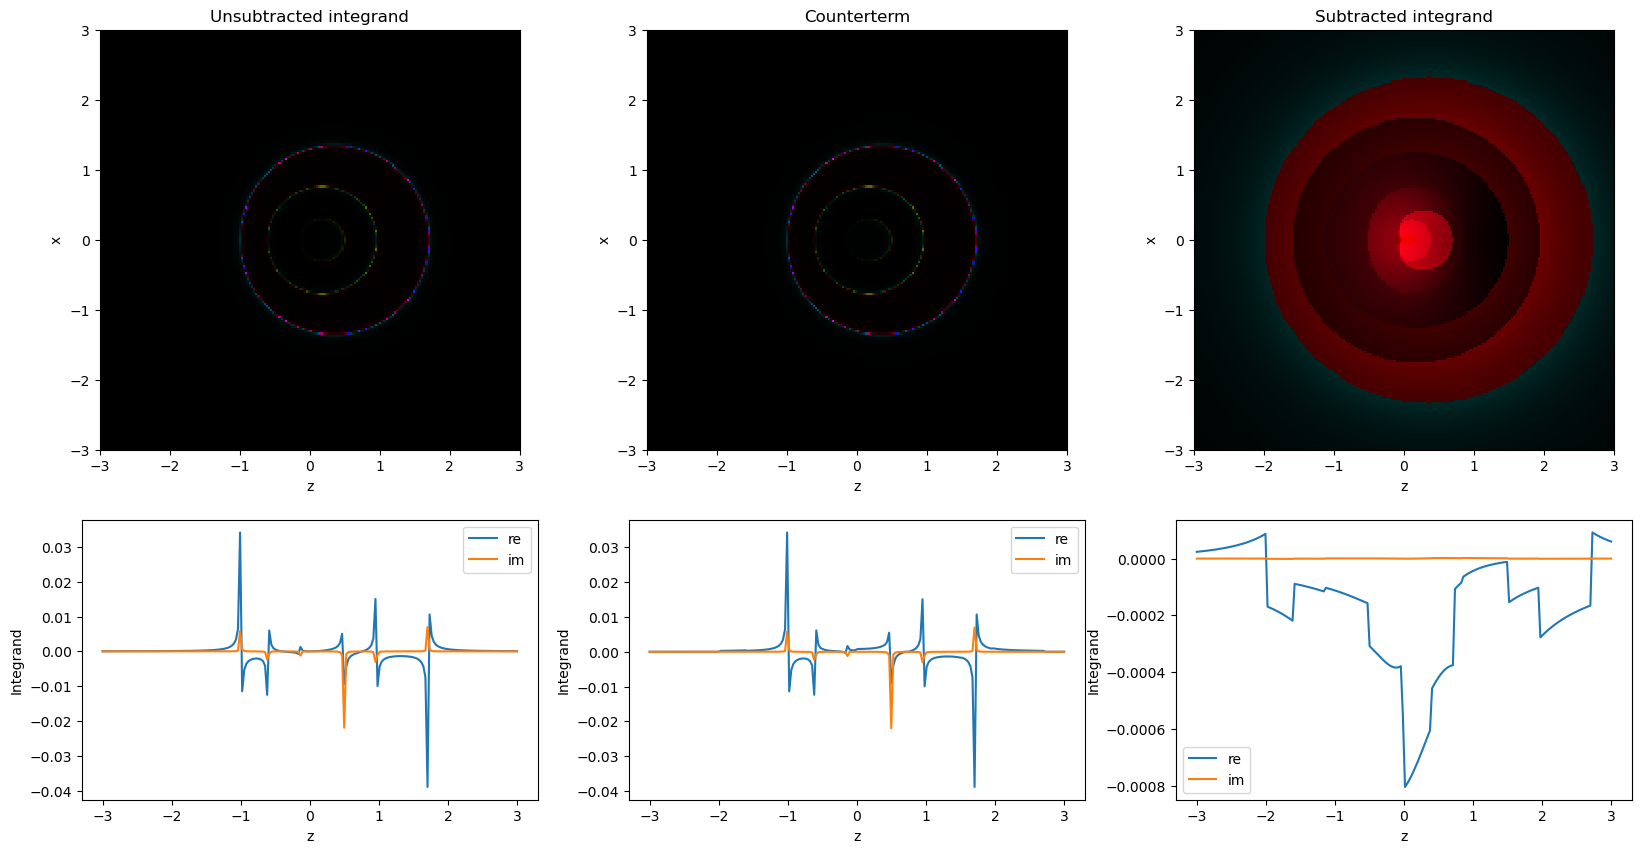

In [17]:
ctx.set_external_momenta(1, 3, 8)

mass = 0.4*(1-0.01j)
ctx.masses = [mass, mass, mass] # type: ignore

ctx.subtraction_width = 2.5
ctx.mask_width = 2.5
centered.plot_threshold_subtraction((-3,3),(-3,3), 2,0)
plt.savefig(f"../images/small_width/centered_subtraction.png", dpi=300)
plt.show()

ctx.subtraction_width = 1
ctx.mask_width = 1
uncentered.plot_threshold_subtraction((-3,3),(-3,3), 2,0)
plt.savefig(f"../images/small_width/uncentered_subtraction.png", dpi=300)
plt.show()

variable.plot_threshold_subtraction((-3,3),(-3,3), 2,0)
plt.savefig(f"../images/small_width/variable_subtraction.png", dpi=300)
plt.show()

In [18]:
from symbolica import RandomNumberGenerator
rng = RandomNumberGenerator(0,0)

In [19]:
from context import spherical
from integrator import ComplexIntegrator


def integrate_over_masses(masses, triangle, epochs = 100, steps = 500):
    results = []
    for m in tqdm(masses):
        ctx.masses = [m, m, m]
        
        ci = ComplexIntegrator(3)
        results.append(ci.integrate(triangle.eval, spherical, epochs, steps, rng))
        
        
    return results

def reference_over_masses(masses):
    ref = []
    for m in masses:
        ctx.masses = [m, m, m]
        ref.append(ctx.get_reference())
    return np.array(ref)

In [20]:
mass = 0.4
sample_gammas =  0.1*0.0001**np.linspace(0,1,21)
sample_masses = mass * (1-1j*sample_gammas)

ref_gammas = 0.1*0.0001**np.linspace(0,1,50)
ref_masses = mass * (1-1j*ref_gammas)

ctx.combined_integrand()

ctx.subtraction_width = 2.5 # type: ignore
ctx.mask_width = 2.5 # type: ignore
centered_res = integrate_over_masses(sample_masses, centered)


ctx.subtraction_width = 1
ctx.mask_width = 1
uncentered_res = integrate_over_masses(sample_masses, uncentered)
variable_res = integrate_over_masses(sample_masses, variable)

ctx.only_unsubtracted()
unsubtracted_res = integrate_over_masses(sample_masses, centered)

ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

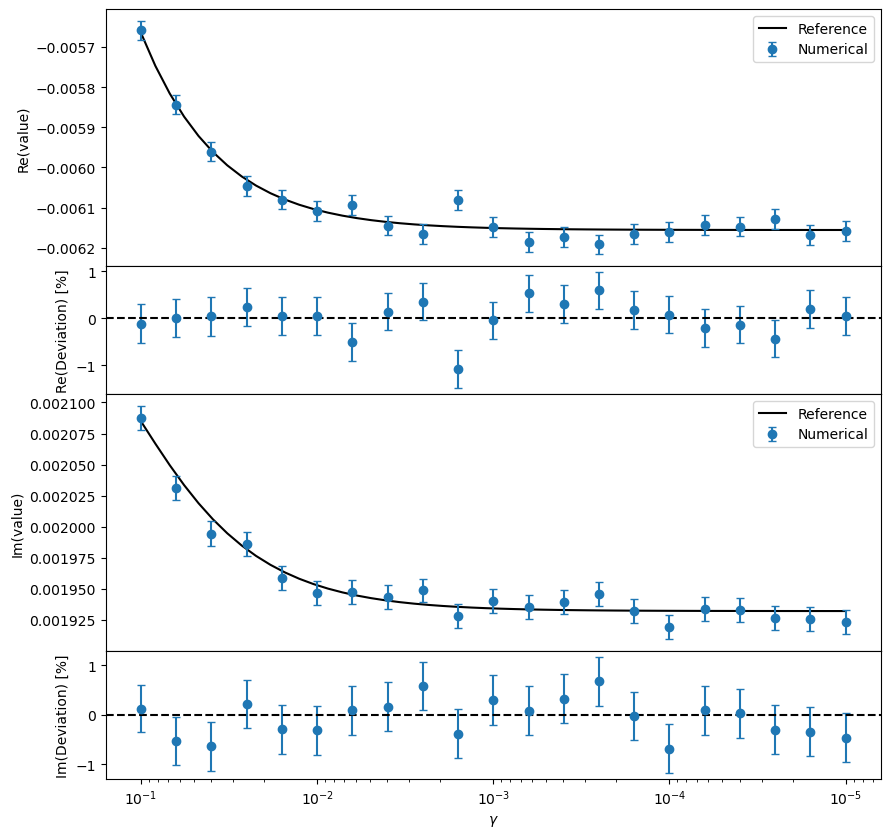

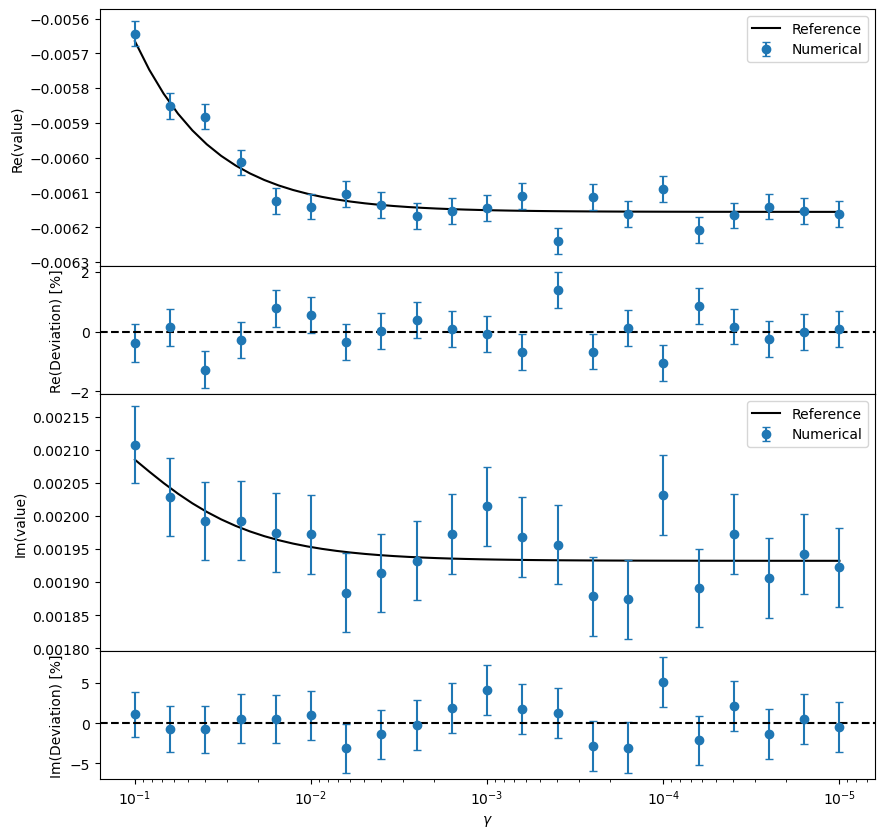

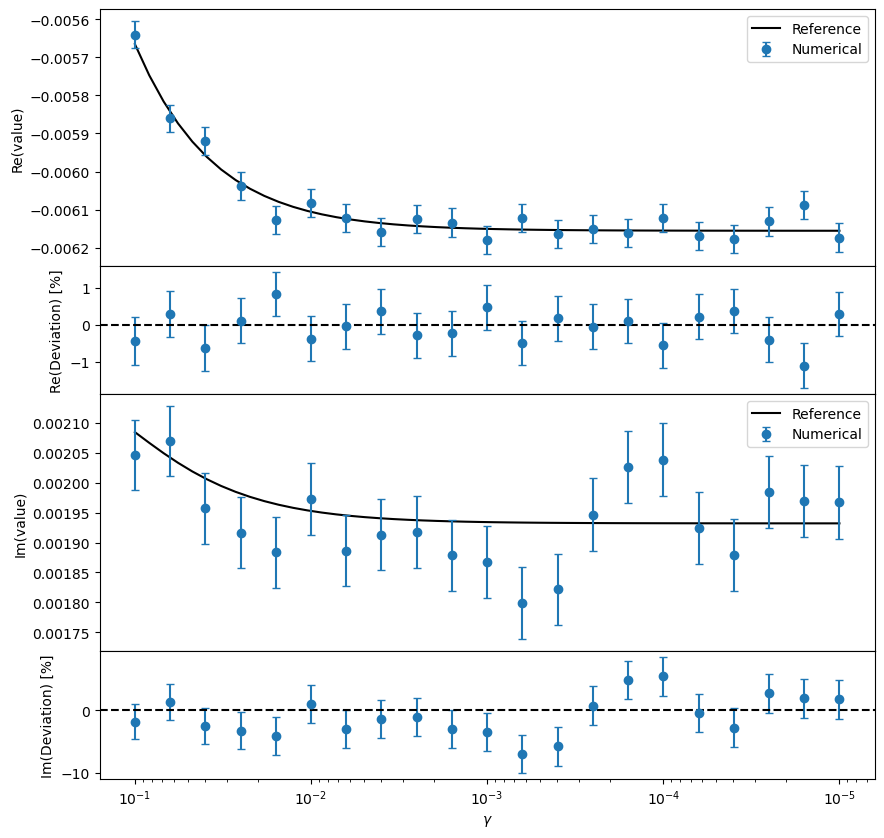

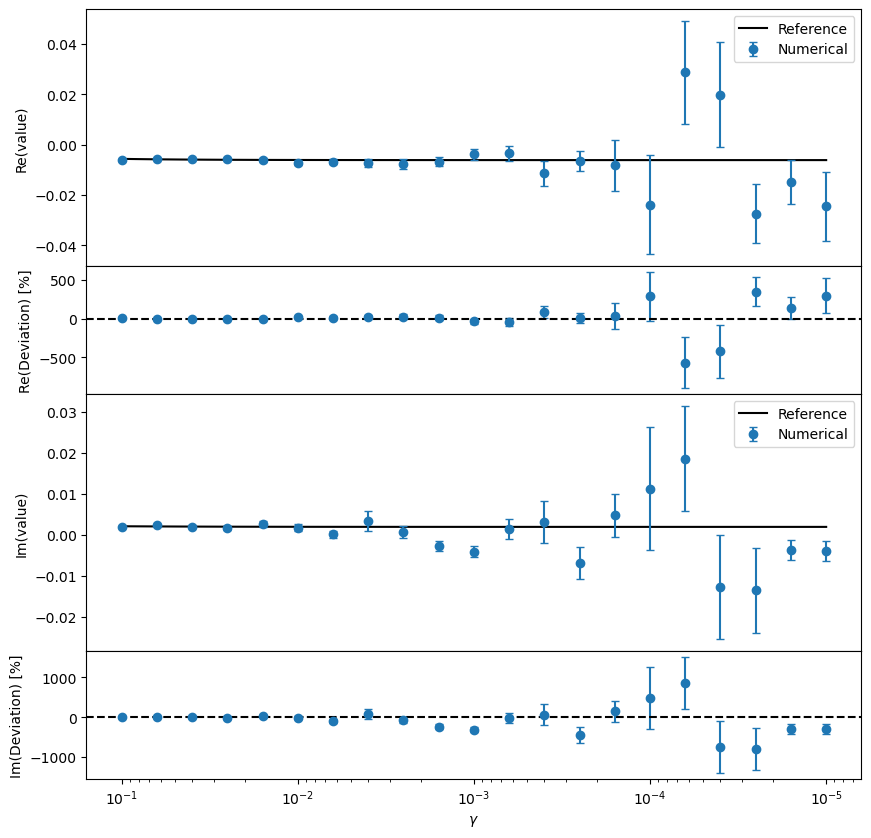

In [21]:
from plot_util import plot_complex_integration_with_ref

fig = plot_complex_integration_with_ref(
    centered_res, ref_same_x, sample_gammas, ref, ref_gammas
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].set_xlabel('$\\gamma$')
plt.gca().invert_xaxis()
plt.savefig(f"../images/small_width/integration_centered.png", dpi=300)
plt.show()


fig = plot_complex_integration_with_ref(
    uncentered_res, ref_same_x, sample_gammas, ref, ref_gammas
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].set_xlabel('$\\gamma$')
plt.gca().invert_xaxis()
plt.savefig(f"../images/small_width/integration_uncentered.png", dpi=300)
plt.show()

fig = plot_complex_integration_with_ref(
    variable_res, ref_same_x, sample_gammas, ref, ref_gammas
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].set_xlabel('$\\gamma$')
plt.gca().invert_xaxis()
plt.savefig(f"../images/small_width/integration_variable.png", dpi=300)
plt.show()


fig = plot_complex_integration_with_ref(
    unsubtracted_res, ref_same_x, sample_gammas, ref, ref_gammas
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].set_xlabel('$\\gamma$')
plt.gca().invert_xaxis()
plt.savefig(f"../images/small_width/integration_unsubtracted.png", dpi=300)
plt.show()


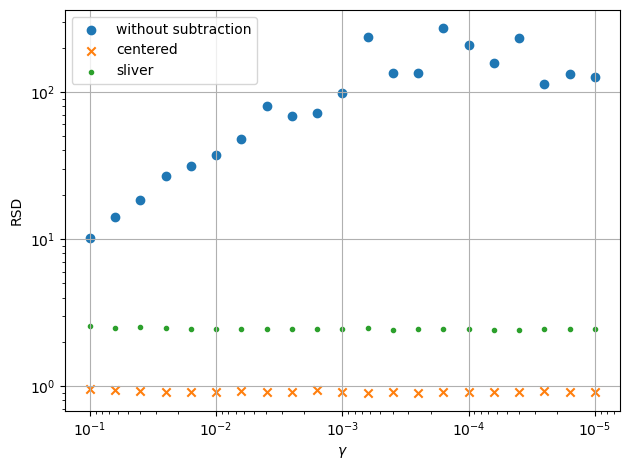

In [22]:
plt.scatter(sample_gammas, [r.rsd() for r in unsubtracted_res], label = 'without subtraction', marker='o')
plt.scatter(sample_gammas, [r.rsd() for r in centered_res],  label = 'centered', marker='x')
plt.scatter(sample_gammas, [r.rsd() for r in uncentered_res],  label = 'sliver', marker='.')
#plt.scatter(sample_gammas, [r.rsd() for r in variable_res],  label = 'variable', marker='*')
plt.xscale('log')
plt.gca().invert_xaxis()
plt.yscale('log')
plt.xlabel('$\\gamma$')
plt.ylabel('RSD')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"../images/small_width/rsd.png", dpi=300)
plt.show()